In [1]:
# ==============================
#  Import Required Libraries
# ==============================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [2]:
# ==============================
#   Define Dataset Paths
# ==============================

# Update these paths to your dataset directories
train_path = r'C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\train'
valid_path = r'C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\validation'
test_path  = r'C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\test'

BATCH_SIZE = 16  # Recommended for medical dataset
IMG_SIZE = (224, 224)

In [3]:
# ==============================
#  Data Preprocessing
# ==============================

# DenseNet121 requires its own preprocessing function
def tl_preprocess(x):
    return preprocess_input(x)

# Create ImageDataGenerators for train, validation, and test
tl_train_datagen = ImageDataGenerator(
    preprocessing_function=tl_preprocess
)

tl_valid_datagen = ImageDataGenerator(
    preprocessing_function=tl_preprocess
)

tl_test_datagen = ImageDataGenerator(
    preprocessing_function=tl_preprocess
)

# Load images from directories
tl_train_generator = tl_train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

tl_valid_generator = tl_valid_datagen.flow_from_directory(
    valid_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

tl_test_generator = tl_test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 57832 images belonging to 4 classes.
Found 7232 images belonging to 4 classes.
Found 7232 images belonging to 4 classes.


In [4]:
# ==============================
# Load Pretrained DenseNet121
# ==============================

# Load DenseNet121 pretrained on ImageNet
base_model = DenseNet121(
    weights='imagenet',       # Use pretrained ImageNet weights
    include_top=False,        # Remove original classification head
    input_shape=(224,224,3)   # Input shape must match dataset
)

# Freeze the base model for feature extraction phase
base_model.trainable = False


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 43s 1us/step


In [5]:
# ==============================
#  Build Custom Classification Head
# ==============================

model = keras.Sequential([
    
    base_model,                              # Pretrained feature extractor
    
    keras.layers.GlobalAveragePooling2D(),   # Convert feature maps to vector
    
    keras.layers.BatchNormalization(),       # Stabilize training
    
    keras.layers.Dense(256, activation='relu'),  # Fully connected layer
    
    keras.layers.Dropout(0.5),               # Reduce overfitting
    
    keras.layers.Dense(4, activation='softmax')  # Output layer (4 classes)
])


In [6]:
# ==============================
#  Compile Model (Feature Extraction Phase)
# ==============================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # Small learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
# ==============================
#  Callbacks (Professional Setup)
# ==============================

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_densenet121_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    verbose=1
)

callbacks = [early_stopping, model_checkpoint, reduce_lr]


In [8]:
# ==============================
#  Train (Feature Extraction)
# ==============================

history = model.fit(
    tl_train_generator,
    epochs=20,                    # EarlyStopping will stop automatically
    validation_data=tl_valid_generator,
    callbacks=callbacks
)

Epoch 1/20


C:\Users\hp\Desktop\Brave_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 862ms/step - accuracy: 0.7816 - loss: 0.5902
Epoch 1: val_loss improved from inf to 0.22658, saving model to best_densenet121_model.keras
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 3512s 969ms/step - accuracy: 0.7816 - loss: 0.5901 - val_accuracy: 0.9217 - val_loss: 0.2266 - learning_rate: 1.0000e-04
Epoch 2/20
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 762ms/step - accuracy: 0.8961 - loss: 0.2904
Epoch 2: val_loss improved from 0.22658 to 0.18433, saving model to best_densenet121_model.keras
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 3101s 857ms/step - accuracy: 0.8961 - loss: 0.2904 - val_accuracy: 0.9351 - val_loss: 0.1843 - learning_rate: 1.0000e-04
Epoch 3/20
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 814ms/step - accuracy: 0.9165 - loss: 0.2367
Epoch 3: val_loss improved from 0.18433 to 0.16442, saving model to best_densenet121_model.keras
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 3239s 896ms/step - accuracy: 0.9165 - loss: 0.2367 - val_accuracy: 0.9418 - val_loss: 0.1644 - learning_rate: 1.0000e-0

In [9]:
# ==============================
#  Fine-Tuning Phase
# ==============================

# Unfreeze last 20 layers of DenseNet121
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train again (fine-tuning)
fine_tune_history = model.fit(
    tl_train_generator,
    epochs=15,
    validation_data=tl_valid_generator,
    callbacks=callbacks
)

Epoch 1/15
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 867ms/step - accuracy: 0.9640 - loss: 0.1009
Epoch 1: val_loss did not improve from 0.10056
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 3519s 971ms/step - accuracy: 0.9640 - loss: 0.1009 - val_accuracy: 0.9663 - val_loss: 0.1035 - learning_rate: 1.0000e-05
Epoch 2/15
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.9671 - loss: 0.0935
Epoch 2: val_loss did not improve from 0.10056
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 3425s 947ms/step - accuracy: 0.9671 - loss: 0.0935 - val_accuracy: 0.9681 - val_loss: 0.1011 - learning_rate: 1.0000e-05
Epoch 3/15
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.9703 - loss: 0.0865
Epoch 3: val_loss did not improve from 0.10056
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 3427s 948ms/step - accuracy: 0.9703 - loss: 0.0865 - val_accuracy: 0.9682 - val_loss: 0.1008 - learning_rate: 1.0000e-05
Epoch 4/15
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9697 - loss: 0.0856
Epoch 4: val_loss improved from 0.10056 to 0.0

In [10]:
# ==============================
#  Evaluate Model
# ==============================

test_loss, test_accuracy = model.evaluate(tl_test_generator)

print("Test Accuracy:", test_accuracy)

452/452 ━━━━━━━━━━━━━━━━━━━━ 400s 885ms/step - accuracy: 0.9720 - loss: 0.0893
Test Accuracy: 0.9727599620819092


452/452 ━━━━━━━━━━━━━━━━━━━━ 380s 836ms/step


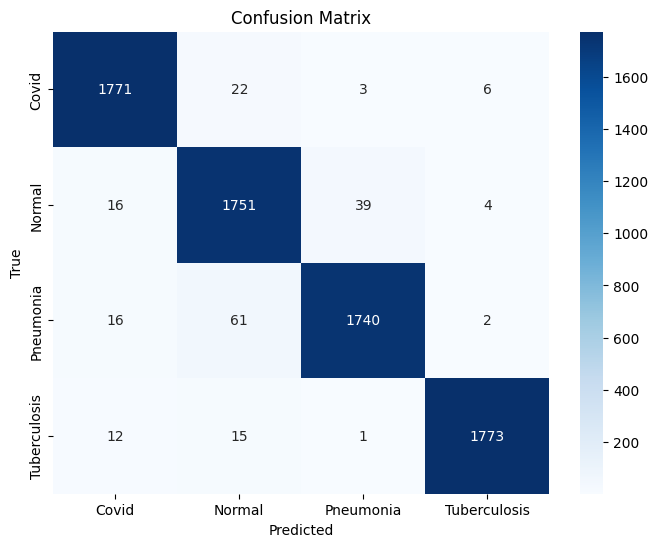

Classification Report:

              precision    recall  f1-score   support

       Covid       0.98      0.98      0.98      1802
      Normal       0.95      0.97      0.96      1810
   Pneumonia       0.98      0.96      0.97      1819
Tuberculosis       0.99      0.98      0.99      1801

    accuracy                           0.97      7232
   macro avg       0.97      0.97      0.97      7232
weighted avg       0.97      0.97      0.97      7232



In [11]:
# ==============================
# Confusion Matrix & Classification Report
# ==============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
Y_pred = model.predict(tl_test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# True labels
y_true = tl_test_generator.classes

# Class labels
class_labels = list(tl_test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

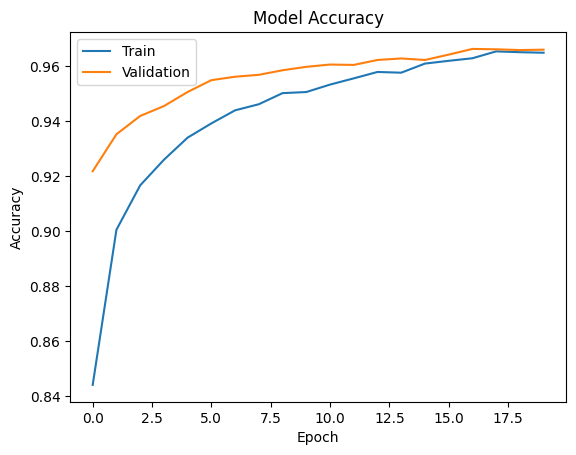

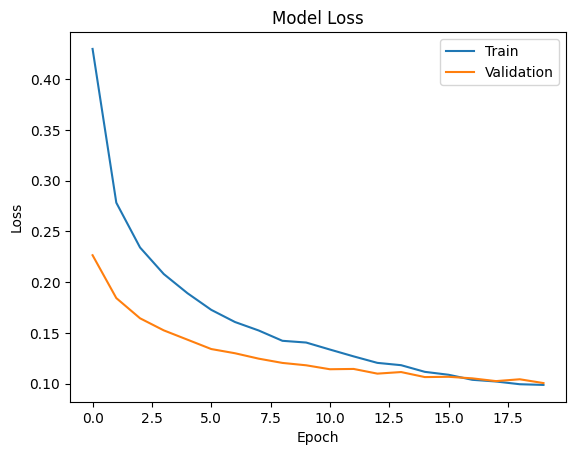

In [12]:
# ==============================
# Plot Training History
# ==============================

def plot_history(history):
    
    # Accuracy plot
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'])
    plt.show()
    
    # Loss plot
    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'])
    plt.show()

plot_history(history)

In [13]:
# ==============================
# Functional Model (Grad-CAM Safe)
# ==============================

from tensorflow.keras import layers, Model

# Base model
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

# Define input explicitly
inputs = layers.Input(shape=(224,224,3))

# Forward pass through DenseNet121
x = base_model(inputs, training=False)

# Custom head
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(4, activation='softmax')(x)

# Create model
model = Model(inputs, outputs)

In [14]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # Get DenseNet121 layer
    last_conv_layer = model.get_layer("densenet121").get_layer(last_conv_layer_name)

    # Create grad model
    grad_model = Model(
        [model.input],
        [last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [15]:
img_path = r"C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\test\Covid\00f9707e0de334db70a7924a9de98368.jpg"

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

heatmap = make_gradcam_heatmap(img_array, model, "conv5_block16_concat")

plt.matshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.show()

KeyError: 'Exception encountered when calling Functional.call().\n\n\x1b[1m2497639842624\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[-2.117904  , -2.0357141 , -1.8044444 ],\n         [-2.0665298 , -1.9831933 , -1.7521569 ],\n         [-2.0494049 , -1.9656862 , -1.7347276 ],\n         ...,\n         [ 0.09118938,  0.2226892 ,  0.44392177],\n         [ 0.57068247,  0.71288526,  0.9319392 ],\n         [ 0.63918144,  0.78291327,  1.0016559 ]],\n\n        [[-2.0836544 , -2.0007002 , -1.7695861 ],\n         [-2.0322802 , -1.9481792 , -1.7172985 ],\n         [-1.9980307 , -1.9131652 , -1.68244   ],\n         ...,\n         [-0.11430778,  0.01260505,  0.23477131],\n         [ 0.39943492,  0.5378152 ,  0.7576472 ],\n         [ 0.8446785 ,  0.9929972 ,  1.2108063 ]],\n\n        [[-2.0494049 , -1.9656862 , -1.7347276 ],\n         [-1.9980307 , -1.9131652 , -1.68244   ],\n         [-1.980906  , -1.8956583 , -1.6650109 ],\n         ...,\n         [ 0.12543888,  0.257703

In [16]:
for layer in model.layers:
    print(layer.name)

input_layer_3
densenet121
global_average_pooling2d_1
batch_normalization_1
dense_2
dropout_1
dense_3
